In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, log_loss
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.utils import shuffle

In [16]:
np.random.seed(445)
sound_data = pd.read_csv('sample_features_balanced.csv')
print(sound_data.head())

   core_frequency  max_amplitude  average_activation  duration label
0     1063.171703   3.059000e+04            0.000641  0.087302   hat
1      539.392612   1.027420e+09            0.000793  0.052109   hat
2      540.520182   2.001861e+09            0.002080  0.100000   hat
3      545.707740   9.874376e+08            0.003246  0.755238   hat
4     1963.290826   3.643806e-01            0.000855  0.070612   hat


In [17]:
train_data, test_data = train_test_split(
    sound_data, test_size=0.2, stratify=sound_data["label"], random_state=445)


X_train = train_data.drop(columns=["label"])
Y_train = train_data["label"]
X_test = test_data.drop(columns=["label"])
Y_test = test_data["label"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
ridge_model = LogisticRegressionCV(
    penalty="l2", solver="lbfgs", multi_class="multinomial", cv=5, random_state=445
)
ridge_model.fit(X_train_scaled, Y_train)

lasso_model = LogisticRegressionCV(
    penalty="l1",
    solver="saga",
    multi_class="multinomial",
    cv=5,
    random_state=445,
    max_iter=5000,
)
lasso_model.fit(X_train_scaled, Y_train)

C:\Users\ageck\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1905: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ageck\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1905: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegressionCV(cv=5, max_iter=5000, multi_class='multinomial',
                     penalty='l1', random_state=445, solver='saga')

In [19]:
best_ridge_lambda = 1 / ridge_model.C_[0]  # Convert best C to lambda (1/C)
best_lasso_lambda = 1 / lasso_model.C_[0]

tuned_ridge_model = LogisticRegression(
    penalty="l2", solver="lbfgs", multi_class="multinomial", C=1 / best_ridge_lambda, random_state=445
)
tuned_ridge_model.fit(X_train_scaled, Y_train)

tuned_lasso_model = LogisticRegression(
    penalty="l1",
    solver="saga",
    multi_class="multinomial",
    C=1 / best_lasso_lambda,
    random_state=445,
    max_iter=5000,
)
tuned_lasso_model.fit(X_train_scaled, Y_train)


C:\Users\ageck\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ageck\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=21.54434690031882, max_iter=5000,
                   multi_class='multinomial', penalty='l1', random_state=445,
                   solver='saga')

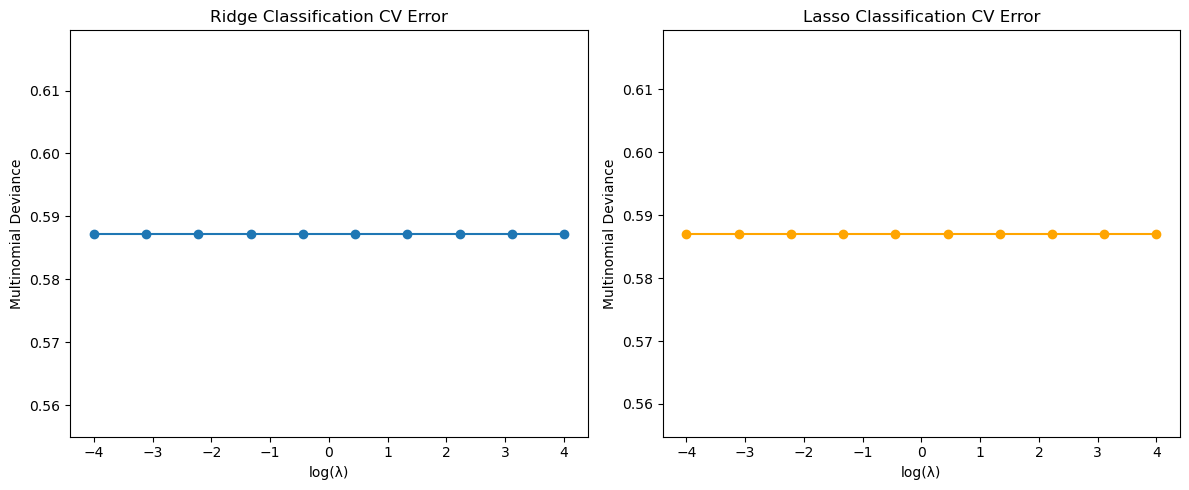

In [20]:
ridge_lambda = 1 / ridge_model.Cs_  # Convert C values to lambda (1/C)
lasso_lambda = 1 / lasso_model.Cs_

ridge_deviances = []
lasso_deviances = []

for i in range(len(ridge_lambda)):
    ridge_probs = ridge_model.predict_proba(X_train_scaled)
    ridge_dev = log_loss(Y_train, ridge_probs, labels=ridge_model.classes_)
    ridge_deviances.append(ridge_dev)

    lasso_probs = lasso_model.predict_proba(X_train_scaled)
    lasso_dev = log_loss(Y_train, lasso_probs, labels=lasso_model.classes_)
    lasso_deviances.append(lasso_dev)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(np.log10(ridge_lambda), ridge_deviances, marker="o")
ax[0].set_xlabel("log(λ)")
ax[0].set_ylabel("Multinomial Deviance")
ax[0].set_title("Ridge Classification CV Error")

ax[1].plot(np.log10(lasso_lambda), lasso_deviances, marker="o", color="orange")
ax[1].set_xlabel("log(λ)")
ax[1].set_ylabel("Multinomial Deviance")
ax[1].set_title("Lasso Classification CV Error")

plt.tight_layout()
plt.show()

In [21]:
ridge_predictions = ridge_model.predict(X_test_scaled)
lasso_predictions = lasso_model.predict(X_test_scaled)

ridge_accuracy = accuracy_score(Y_test, ridge_predictions)
lasso_accuracy = accuracy_score(Y_test, lasso_predictions)

tuned_ridge_predictions = tuned_ridge_model.predict(X_test_scaled)
tuned_lasso_predictions = tuned_lasso_model.predict(X_test_scaled)

tuned_ridge_accuracy = accuracy_score(Y_test, tuned_ridge_predictions)
tuned_lasso_accuracy = accuracy_score(Y_test, tuned_lasso_predictions)

print(f"Ridge Accuracy: {ridge_accuracy * 100:.2f}%")
print(f"Tuned Ridge Accuracy: {tuned_ridge_accuracy * 100:.2f}%")
print(f"Lasso Accuracy: {lasso_accuracy * 100:.2f}%")
print(f"Tuned Lasso Accuracy: {tuned_lasso_accuracy * 100:.2f}%")

Ridge Accuracy: 83.13%
Tuned Ridge Accuracy: 83.13%
Lasso Accuracy: 84.34%
Tuned Lasso Accuracy: 84.34%


In [22]:
ridge_cm = confusion_matrix(Y_test, ridge_predictions, labels=ridge_model.classes_)
lasso_cm = confusion_matrix(Y_test, lasso_predictions, labels=lasso_model.classes_)

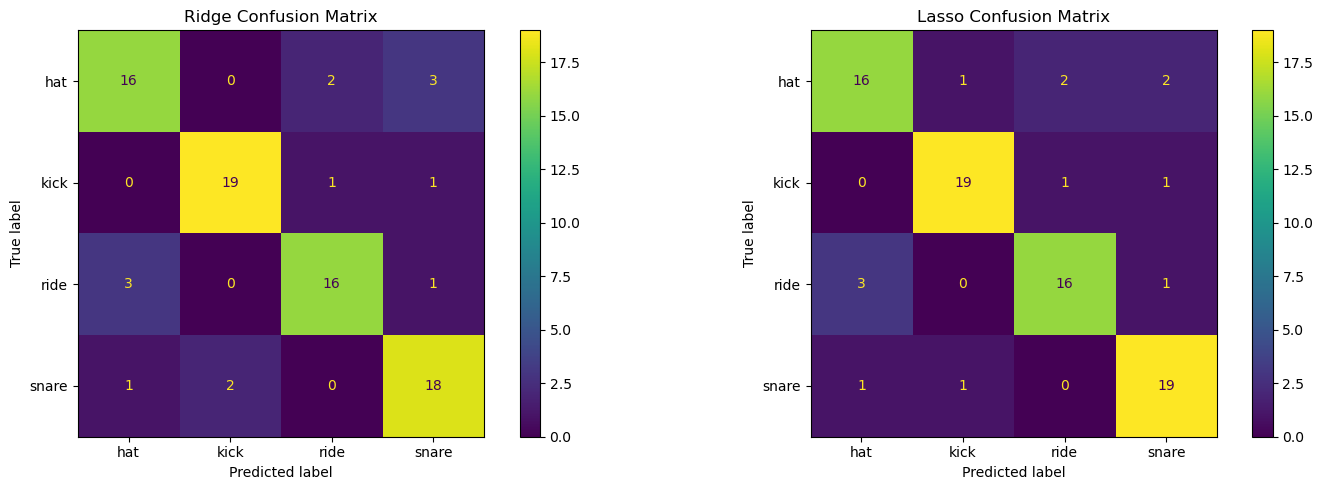

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay(confusion_matrix=ridge_cm, display_labels=ridge_model.classes_).plot(ax=axes[0])
axes[0].set_title("Ridge Confusion Matrix")
ConfusionMatrixDisplay(confusion_matrix=lasso_cm, display_labels=lasso_model.classes_).plot(ax=axes[1])
axes[1].set_title("Lasso Confusion Matrix")
plt.tight_layout()
plt.show()